In [2]:
source("/home/user/data2/lit/bin/lit_utils.R")
lib_text()
lib_plot()

# 饱和度分析

## 旧版本【已弃用】

,reads,unique_genes,unique_isoforms,unique_genes_known,unique_isoforms_known
,<int>,<int>,<int>,<int>,<int>
1,10000,1247,1412,1247,1373
2,20000,2355,2815,2355,2708
3,30000,3219,4048,3219,3874
4,40000,3942,5189,3942,4914
5,50000,4549,6208,4549,5830
6,60000,5065,7132,5065,6659


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


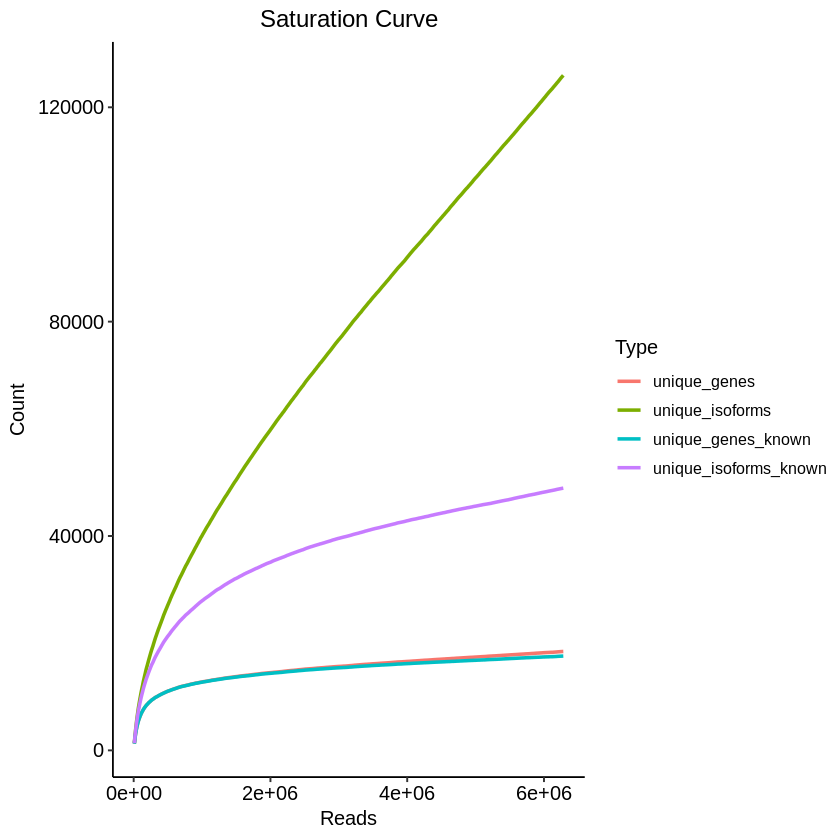

In [2]:
# 加载所需包
library(ggplot2)
library(reshape2)  # 用于数据转换

# 读取数据
df <- read.table("../processed/saturation.txt", header=TRUE, sep="\t")

# 查看前几行
head(df)

# 数据转换为长格式，便于 ggplot2 绘制多条曲线
df_long <- melt(df, id.vars = "reads", 
                measure.vars = c("unique_genes", "unique_isoforms", "unique_genes_known", "unique_isoforms_known"),
                variable.name = "Type", value.name = "Count")

# 绘制饱和曲线
p <- ggplot(df_long, aes(x=reads, y=Count, color=Type)) +
  geom_line(size=1) +
  labs(title="Saturation Curve", x="Reads", y="Count") +
  theme_3() +
  theme(plot.title = element_text(hjust = 0.5))+
theme(legend.position = "right")

print(p)

In [3]:
head(df_long)

,reads,Type,Count
,<int>,<fct>,<int>
1,10000,unique_genes,1247
2,20000,unique_genes,2355
3,30000,unique_genes,3219
4,40000,unique_genes,3942
5,50000,unique_genes,4549
6,60000,unique_genes,5065


In [4]:
ggsave(p,filename = "../figures/saturation.curve.pdf")

Saving 6.67 x 6.67 in image


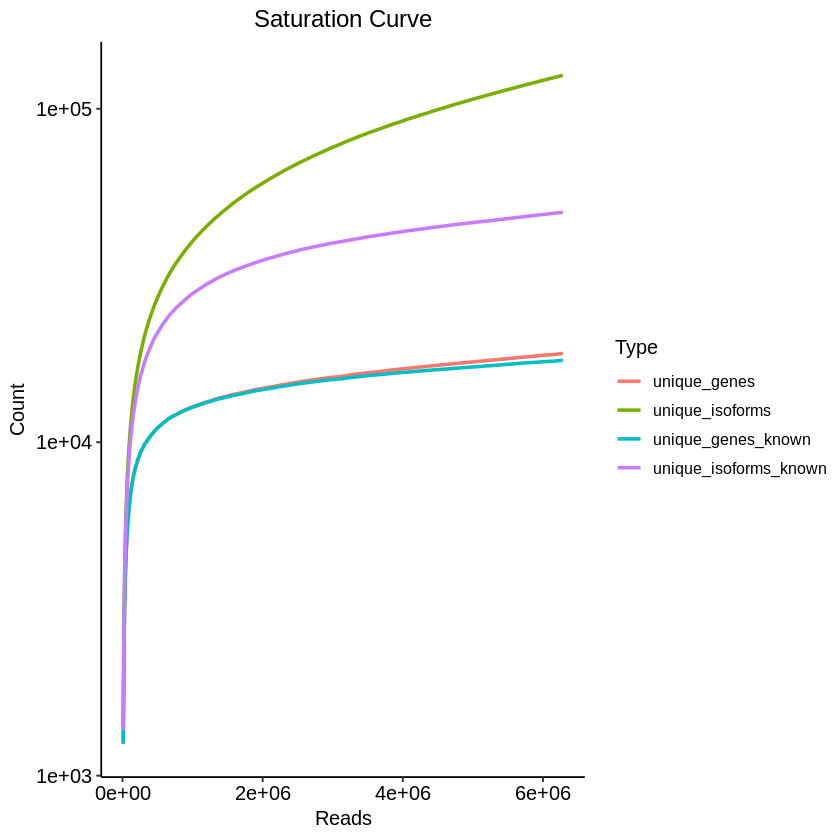

In [5]:
ggplot(df_long, aes(x=reads, y=Count, color=Type)) +
  geom_line(size=1) +
  scale_y_log10() +
  labs(title="Saturation Curve", x="Reads", y="Count") +
  theme_3() +
  theme(plot.title = element_text(hjust = 0.5))+
theme(legend.position = "right")

## 新版本

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


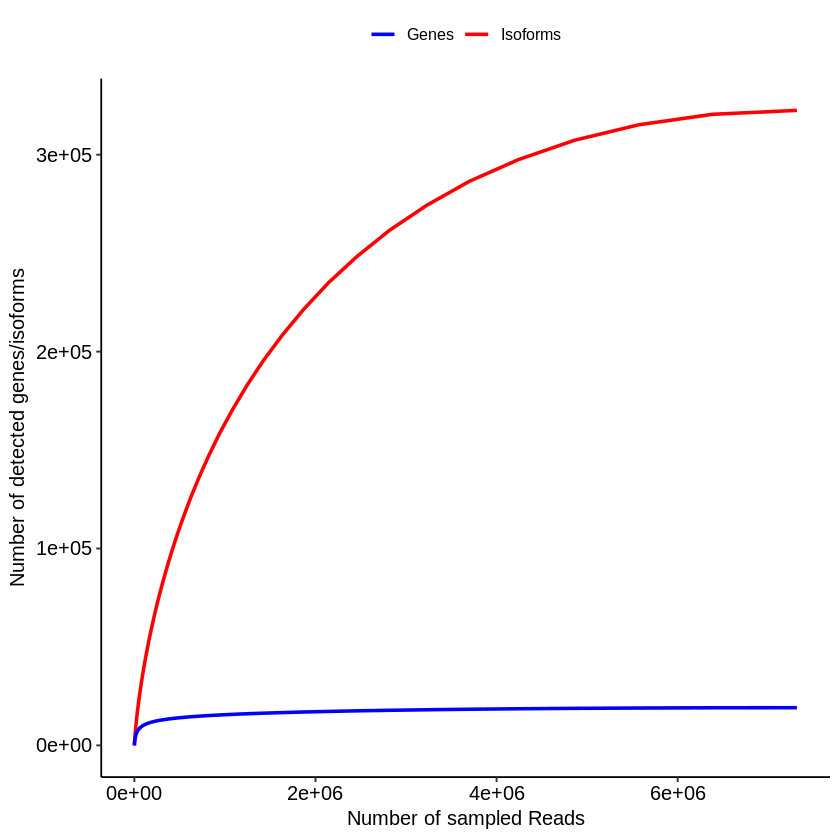

In [3]:
# title = "Isoform and Gene Detection Saturation Curves"
data <- read.table("../results/replicate_15.sample_100_for_r_plotting.txt", header=TRUE, sep="\t")
ggplot(data, aes(x = sample_size)) +
  geom_line(aes(y = mean_isoforms, color = "Isoforms"), size = 1) +
  # geom_point(aes(y = mean_isoforms, color = "Isoforms"), size = 2) +
  geom_line(aes(y = mean_genes, color = "Genes"), size = 1) +
  # geom_point(aes(y = mean_genes, color = "Genes"), size = 2) +
  scale_color_manual(values = c("Isoforms" = "red", "Genes" = "blue")) +
  labs(
       x = "Number of sampled Reads", y = "Number of detected genes/isoforms",color=NULL) +
  theme_3() -> p
p
# 保存图片
ggsave(p,filename = "../figures/saturation_curve_custom.pdf", width = 8, height = 6, dpi = 300)

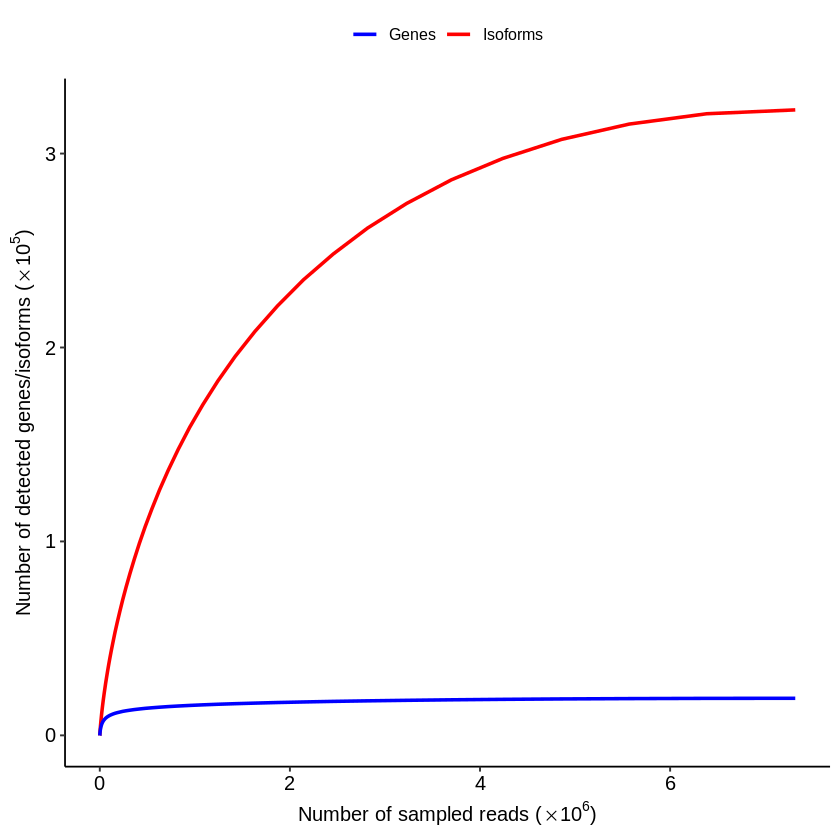

In [16]:
# title = "Isoform and Gene Detection Saturation Curves"
data <- read.table("../results/replicate_15.sample_100_for_r_plotting.txt", header=TRUE, sep="\t")

ggplot(data, aes(x = sample_size)) +
  geom_line(aes(y = mean_isoforms, color = "Isoforms"), size = 1) +
  geom_line(aes(y = mean_genes, color = "Genes"), size = 1) +
  scale_color_manual(values = c("Isoforms" = "red", "Genes" = "blue")) +
  scale_x_continuous(labels = function(x) x / 1e6) +  # 横轴转换为10^6
  scale_y_continuous(labels = function(y) y / 1e5) +  # 纵轴转换为10^5
  labs(
    x = expression("Number of sampled reads (" %*% 10^6 * ")"),
    y = expression("Number of detected genes/isoforms (" %*% 10^5 * ")"),
    color = NULL
  ) +
  theme_3() -> p

p

# 保存图片
ggsave(p, filename = "../figures/saturation_curve_custom.pdf", width = 8, height = 6, dpi = 300)

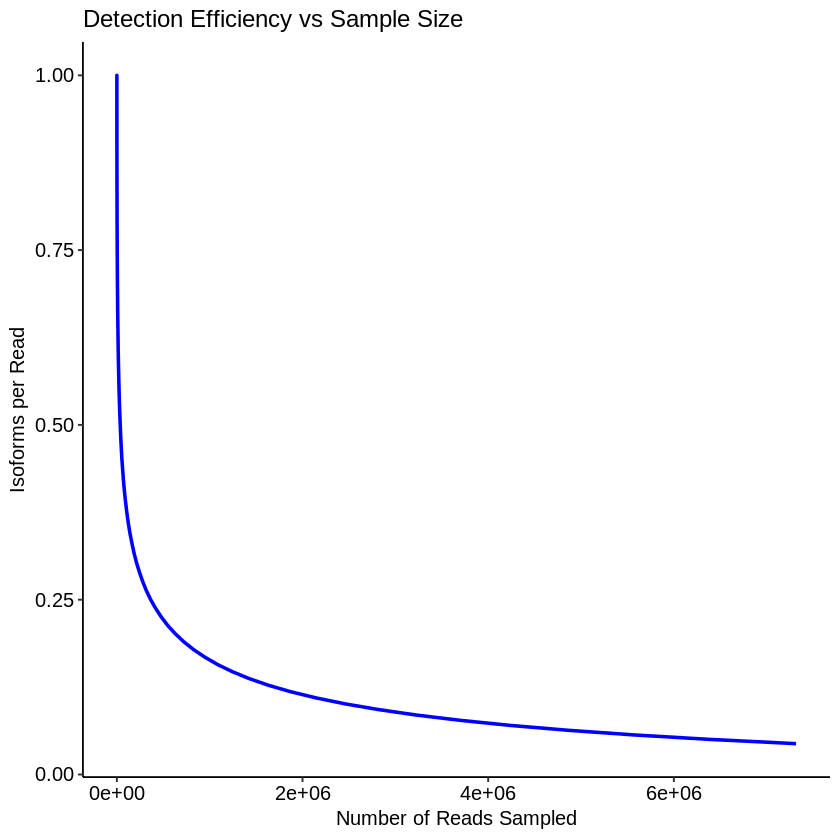

In [11]:
# 绘制效率曲线
ggplot(data, aes(x = sample_size, y = efficiency_isoforms)) +
  geom_line(color = "blue", size = 1) +
  # geom_point(color = "blue", size = 2) +
  labs(title = "Detection Efficiency vs Sample Size",
       x = "Number of Reads Sampled",
       y = "Isoforms per Read") +
  theme_3()

# 保存图片
# ggsave("efficiency_curve.png", width = 8, height = 6, dpi = 300)

# 转录本比例

In [5]:
# 1. 读取数据
df <- read.table("../processed/classify/collapsed_classification.filtered_lite_classification.txt",sep = '\t',header = T)  # 修改为你的文件路径

`summarise()` has grouped output by 'structural_category'. You can override
using the `.groups` argument.


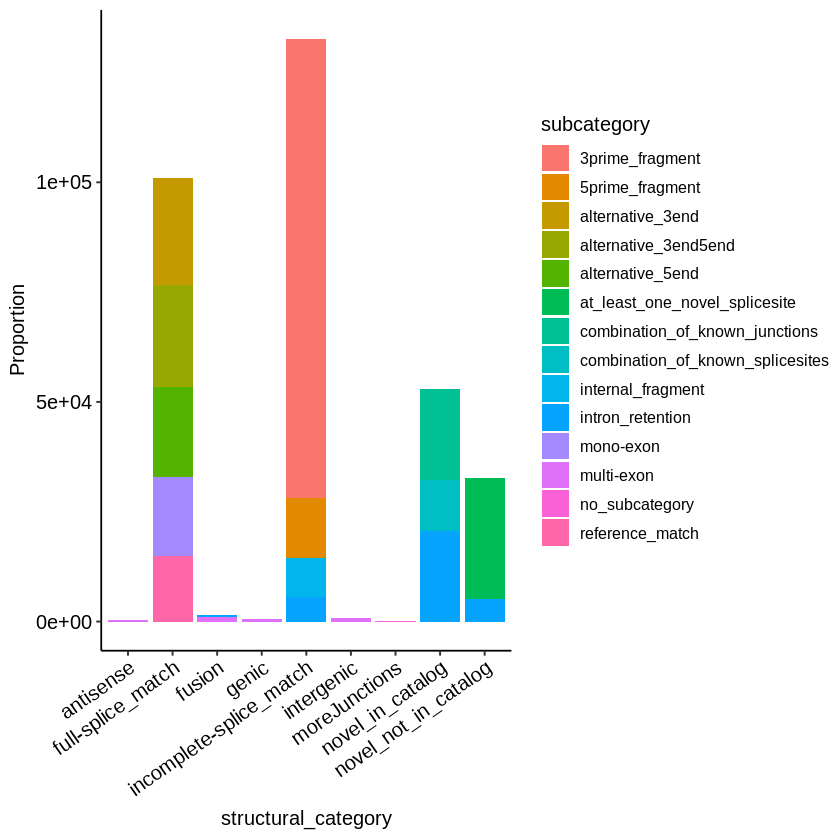

In [11]:
# 2. 统计每个组合的数量
library(dplyr)
counts <- df %>%
  group_by(structural_category, subcategory) %>%
  summarise(count = n())
# 3. 可视化
library(ggplot2)
ggplot(counts, aes(x = structural_category, y = count, fill = subcategory)) +
  geom_bar(stat = "identity") +
  ylab("Proportion") +
theme_3(rotate = T) +
  theme(legend.position = "right")

Saving 6.67 x 6.67 in image


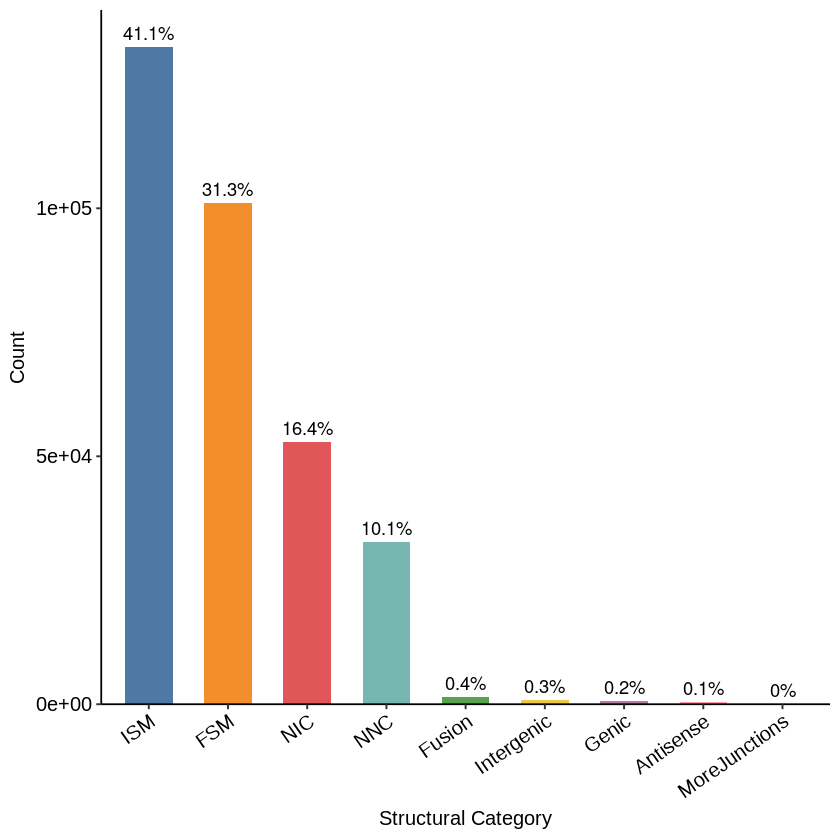

In [10]:
library(dplyr)
library(ggplot2)

# 1. 统计 structural_category 的数量和比例
counts <- df %>%
  count(structural_category) %>%
  mutate(structural_category = recode(structural_category,
    "incomplete-splice_match" = "ISM",
    "full-splice_match" = "FSM",
    "novel_in_catalog" = "NIC",
    "novel_not_in_catalog" = "NNC",
    "fusion" = "Fusion",
    "intergenic" = "Intergenic",
    "genic" = "Genic",
    "antisense" = "Antisense",
    "moreJunctions" = "MoreJunctions"
  )) %>%
  mutate(percentage = n / sum(n),
         label = paste0(round(percentage * 100, 1), "%"))


# 2. 按数量排序
counts <- counts %>%
  arrange(desc(n)) %>%
  mutate(structural_category = factor(structural_category, levels = structural_category))

# 3. 绘图
ggplot(counts, aes(x = structural_category, y = n, fill = structural_category)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = label), vjust = -0.5) +
  ylab("Count") +
  xlab("Structural category") +
guides(fill="none")+
  scale_fill_tableau() +
scale_y_continuous(expand = c(0, 0)) +
theme_3(rotate = T) +
  theme(legend.position = "right")+
coord_cartesian(ylim = c(0, 140000))-> p
p
ggsave(p,filename = "../figures/structural_category.pdf")

## 采用

Saving 6.67 x 6.67 in image


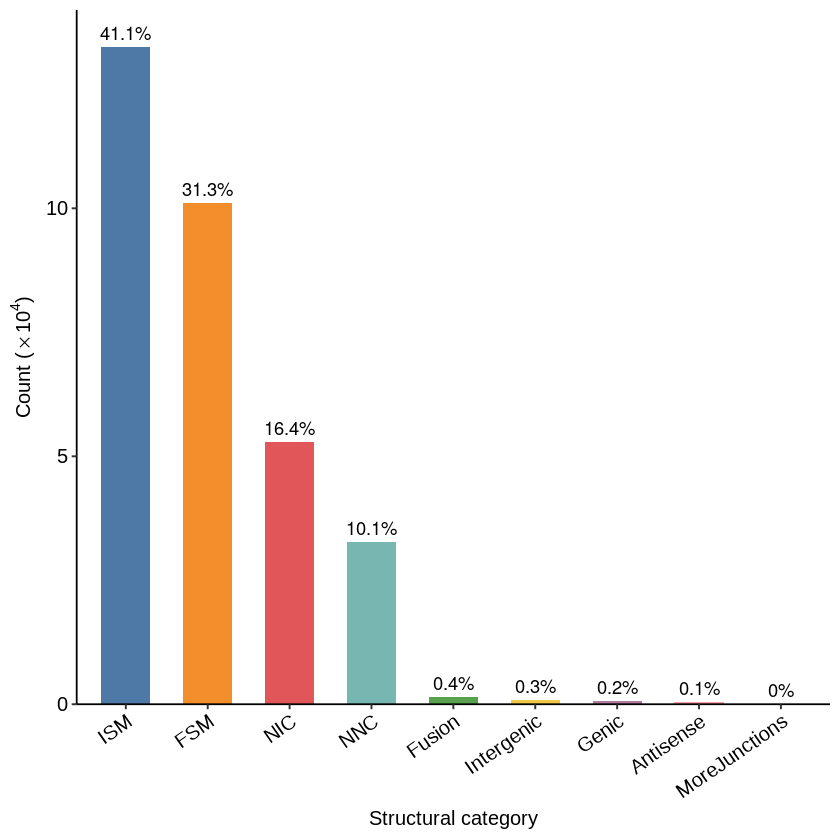

In [14]:
library(dplyr)
library(ggplot2)

# 1. 统计 structural_category 的数量和比例
counts <- df %>%
  count(structural_category) %>%
  mutate(structural_category = recode(structural_category,
    "incomplete-splice_match" = "ISM",
    "full-splice_match" = "FSM",
    "novel_in_catalog" = "NIC",
    "novel_not_in_catalog" = "NNC",
    "fusion" = "Fusion",
    "intergenic" = "Intergenic",
    "genic" = "Genic",
    "antisense" = "Antisense",
    "moreJunctions" = "MoreJunctions"
  )) %>%
  mutate(percentage = n / sum(n),
         label = paste0(round(percentage * 100, 1), "%"))

# 2. 按数量排序
counts <- counts %>%
  arrange(desc(n)) %>%
  mutate(structural_category = factor(structural_category, levels = structural_category))

# 3. 绘图
ggplot(counts, aes(x = structural_category, y = n, fill = structural_category)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = label), vjust = -0.5) +
  ylab(expression("Count (" %*% 10^4 * ")")) +  # 或使用 "Count (万)"
  xlab("Structural category") +
  guides(fill = "none") +
  scale_fill_tableau() +
  scale_y_continuous(
    expand = c(0, 0),
    labels = function(x) x / 10000  # 将数值除以10000，转换为万
  ) +
  theme_3(rotate = T) +
  theme(legend.position = "right") +
  coord_cartesian(ylim = c(0, 140000)) -> p

p
ggsave(p, filename = "../figures/structural_category.pdf")

In [27]:
counts$structural_category

[1] incomplete-splice_match full-splice_match       novel_in_catalog       
[4] novel_not_in_catalog    fusion                  intergenic             
[7] genic                   antisense               moreJunctions          
9 Levels: incomplete-splice_match full-splice_match ... moreJunctions

In [13]:
head(counts)

structural_category,subcategory,count
<chr>,<chr>,<int>
antisense,multi-exon,352
full-splice_match,alternative_3end,24492
full-splice_match,alternative_3end5end,23293
full-splice_match,alternative_5end,20307
full-splice_match,mono-exon,18017
full-splice_match,reference_match,14965
